
# Módulo 4 — Estratégias de Learning Rate (LR)

> **Tema:** Warmup, Step/Exponential decay, Cosine Annealing, One-Cycle, relação LR × batch size, early stopping e checkpoints.  
> **Objetivo didático:** entender **como e por que** ajustar LR ao longo do treino para ganhar estabilidade, velocidade e melhor generalização.

---

## Roteiro da aula

1. Por que LR é o hiperparâmetro mais crítico  
2. Políticas clássicas: constante, step decay, exponential  
3. Políticas modernas: cosine annealing e one-cycle  
4. Warmup: quando ajuda e como implementar  
5. Regra prática: LR × batch size (escala linear)  
6. Early stopping + checkpoints (treino robusto)



## 0) Setup

> Notebook em PyTorch com exemplos didáticos e gráficos.  
> Funciona em CPU; se houver GPU, o treino será mais rápido.


In [1]:

# =========================
# Setup e bibliotecas
# =========================
import os
import math
import random
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader

from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score

# Reprodutibilidade (importante para ensino)
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)


Device: cuda



## 1) Intuição: por que LR é tão importante?

A atualização básica é:

\[
$\theta_{t+1} = \theta_t - \eta_t \nabla L(\theta_t)$
\]

- Se \($\eta$\) (LR) é **muito pequeno**: treino lento (pode parecer “não aprende”).  
- Se \($\eta$\) é **muito grande**: oscila/diverge (loss instável).  
- O ideal costuma ser começar com um LR razoável e **variar ao longo do treino** com scheduler.


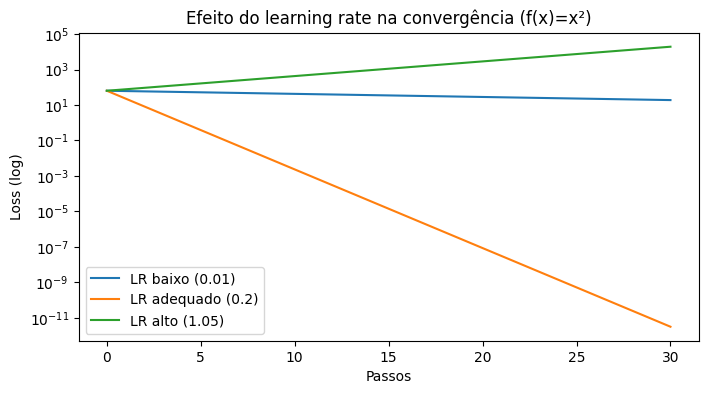

In [2]:

# ===========================================
# Demonstração visual simples em função 1D
# ===========================================
# f(x) = x^2 -> grad = 2x

def run_gd_1d(lr, x0=8.0, steps=30):
    x = x0
    xs, losses = [x], [x*x]
    for _ in range(steps):
        grad = 2*x
        x = x - lr*grad
        xs.append(x)
        losses.append(x*x)
    return np.array(xs), np.array(losses)

lrs = [0.01, 0.2, 1.05]  # baixo, bom, alto (instável)
labels = ["LR baixo", "LR adequado", "LR alto"]

plt.figure(figsize=(8,4))
for lr, lb in zip(lrs, labels):
    _, losses = run_gd_1d(lr)
    plt.plot(losses, label=f"{lb} ({lr})")
plt.yscale("log")
plt.xlabel("Passos")
plt.ylabel("Loss (log)")
plt.title("Efeito do learning rate na convergência (f(x)=x²)")
plt.legend()
plt.show()



### Leitura do gráfico
- **LR baixo**: converge, mas lentamente.
- **LR adequado**: converge rápido e estável.
- **LR alto**: pode oscilar ou divergir.

Em redes profundas, isso fica mais sensível por causa de não linearidades, normalização e ruído de mini-batch.



## 2) Base experimental: dataset + modelo

Usaremos `make_moons` (classificação binária não linear) para comparar schedulers com custo baixo.


In [3]:

# =====================================
# Dataset
# =====================================
X, y = make_moons(n_samples=3500, noise=0.25, random_state=SEED)

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.30, random_state=SEED, stratify=y
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)

X_train_t = torch.tensor(X_train, dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.float32).unsqueeze(1)
X_val_t = torch.tensor(X_val, dtype=torch.float32)
y_val_t = torch.tensor(y_val, dtype=torch.float32).unsqueeze(1)

def make_loaders(batch_size=64):
    train_loader = DataLoader(TensorDataset(X_train_t, y_train_t), batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(TensorDataset(X_val_t, y_val_t), batch_size=256, shuffle=False)
    return train_loader, val_loader

print("Train:", X_train_t.shape, "Val:", X_val_t.shape)


Train: torch.Size([2450, 2]) Val: torch.Size([1050, 2])


In [4]:

# =====================================
# Modelo MLP simples
# =====================================
class MLP(nn.Module):
    def __init__(self, dropout=0.1):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(2, 64),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(64, 64),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(64, 1)
        )

    def forward(self, x):
        return self.net(x)

def evaluate(model, loader):
    model.eval()
    losses, ys, ps = [], [], []
    with torch.no_grad():
        for xb, yb in loader:
            xb, yb = xb.to(device), yb.to(device)
            logits = model(xb)
            loss = F.binary_cross_entropy_with_logits(logits, yb)
            losses.append(loss.item())
            prob = torch.sigmoid(logits)
            ys.append(yb.cpu().numpy())
            ps.append(prob.cpu().numpy())

    y_true = np.vstack(ys).ravel()
    y_prob = np.vstack(ps).ravel()
    y_pred = (y_prob >= 0.5).astype(int)

    return {
        "loss": float(np.mean(losses)),
        "acc": accuracy_score(y_true, y_pred),
        "f1": f1_score(y_true, y_pred),
        "auc": roc_auc_score(y_true, y_prob),
    }



## 3) Função de treino com scheduler e registro de LR

A ideia é manter tudo igual e mudar apenas a política de LR.


In [5]:

# =====================================
# Treino com scheduler
# =====================================
def train_model(
    optimizer_name="adamw",
    lr=1e-3,
    weight_decay=1e-2,
    epochs=40,
    batch_size=64,
    scheduler_kind="constant",  # constant | step | exp | cosine | warmup_cosine | onecycle
    step_size=12,
    gamma=0.5,
    warmup_epochs=5,
):
    torch.manual_seed(SEED)
    model = MLP(dropout=0.1).to(device)
    train_loader, val_loader = make_loaders(batch_size)

    # Otimizador
    if optimizer_name.lower() == "adamw":
        optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    elif optimizer_name.lower() == "sgd_momentum":
        optimizer = torch.optim.SGD(model.parameters(), lr=lr, momentum=0.9, nesterov=True, weight_decay=weight_decay)
    else:
        raise ValueError("optimizer_name deve ser 'adamw' ou 'sgd_momentum'")

    # Scheduler
    scheduler = None

    if scheduler_kind == "constant":
        scheduler = None

    elif scheduler_kind == "step":
        scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=step_size, gamma=gamma)

    elif scheduler_kind == "exp":
        scheduler = torch.optim.lr_scheduler.ExponentialLR(optimizer, gamma=gamma)

    elif scheduler_kind == "cosine":
        scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs, eta_min=lr*0.01)

    elif scheduler_kind == "warmup_cosine":
        # Warmup linear até 1.0 e depois cosine decay.
        def lr_lambda(current_epoch):
            if current_epoch < warmup_epochs:
                return float(current_epoch + 1) / float(max(1, warmup_epochs))
            progress = (current_epoch - warmup_epochs) / float(max(1, epochs - warmup_epochs))
            cosine = 0.5 * (1 + math.cos(math.pi * progress))
            return max(0.01, cosine)  # piso relativo
        scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda=lr_lambda)

    elif scheduler_kind == "onecycle":
        # One-Cycle atualiza por batch
        scheduler = torch.optim.lr_scheduler.OneCycleLR(
            optimizer,
            max_lr=lr,
            steps_per_epoch=len(train_loader),
            epochs=epochs,
            pct_start=0.3,
            anneal_strategy="cos",
            div_factor=25.0,
            final_div_factor=1e4,
        )
    else:
        raise ValueError("scheduler_kind inválido")

    history = {"train_loss": [], "val_loss": [], "val_f1": [], "val_auc": [], "lr": []}

    for epoch in range(epochs):
        model.train()
        batch_losses = []

        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)

            optimizer.zero_grad()
            logits = model(xb)
            loss = F.binary_cross_entropy_with_logits(logits, yb)
            loss.backward()
            optimizer.step()

            if scheduler_kind == "onecycle" and scheduler is not None:
                scheduler.step()

            batch_losses.append(loss.item())

        if scheduler_kind in ["step", "exp", "cosine", "warmup_cosine"] and scheduler is not None:
            scheduler.step()

        train_loss = float(np.mean(batch_losses))
        val_metrics = evaluate(model, val_loader)

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_metrics["loss"])
        history["val_f1"].append(val_metrics["f1"])
        history["val_auc"].append(val_metrics["auc"])
        history["lr"].append(optimizer.param_groups[0]["lr"])

    return model, history



## 4) Comparando políticas de LR

Vamos comparar em AdamW:
- constante
- step decay
- exponential decay
- cosine annealing
- warmup + cosine
- one-cycle


In [6]:
# Experimento 1: Visualizador de Políticas de LR (Scheduler Playground)
import torch
import torch.optim as optim
import matplotlib.pyplot as plt
import numpy as np
from ipywidgets import interact, Dropdown, IntSlider, FloatSlider

def plot_scheduler_shape(policy, epochs=100, base_lr=0.001, max_lr=0.01):
    model = torch.nn.Linear(1, 1)
    optimizer = optim.SGD(model.parameters(), lr=base_lr)

    lrs = []

    # Configurar Scheduler baseado na escolha
    if policy == 'Step Decay':
        # Cai a cada 30 épocas por fator de 0.1
        scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=30, gamma=0.1)
    elif policy == 'Cosine Annealing':
        # Desce suavemente seguindo uma curva cosseno
        scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)
    elif policy == 'OneCycle':
        # Sobe até max_lr e depois desce (Super-convergence)
        # Nota: OneCycle precisa ser chamado a cada STEP, não época. Aqui simulamos steps = epochs.
        scheduler = optim.lr_scheduler.OneCycleLR(optimizer, max_lr=max_lr,
                                                  total_steps=epochs, pct_start=0.3)
    elif policy == 'Exponential':
        scheduler = optim.lr_scheduler.ExponentialLR(optimizer, gamma=0.95)

    # Simular o Treino
    for epoch in range(epochs):
        optimizer.step()
        lrs.append(optimizer.param_groups[0]['lr'])
        scheduler.step()

    # Plot
    plt.figure(figsize=(10, 5))
    plt.plot(lrs, linewidth=3, color='purple')
    plt.title(f"Perfil da Taxa de Aprendizado: {policy}")
    plt.xlabel("Épocas / Passos")
    plt.ylabel("Learning Rate")
    plt.grid(True, alpha=0.3)
    plt.show()

print("Compare as estratégias modernas (OneCycle, Cosine) com as clássicas (Step).")
interact(plot_scheduler_shape,
         policy=Dropdown(options=['Step Decay', 'Cosine Annealing', 'OneCycle', 'Exponential'], value='Cosine Annealing'),
         epochs=IntSlider(min=50, max=200, step=10, value=100),
         base_lr=FloatSlider(min=1e-4, max=1e-2, step=1e-4, value=1e-3, readout_format='.4f'),
         max_lr=FloatSlider(min=1e-3, max=1e-1, step=1e-3, value=1e-2, description='Max LR (1Cycle)'));

Compare as estratégias modernas (OneCycle, Cosine) com as clássicas (Step).


interactive(children=(Dropdown(description='policy', index=1, options=('Step Decay', 'Cosine Annealing', 'OneC…

In [7]:

# =====================================
# Rodar experimento de comparação
# =====================================
experiments = {
    "constant":      dict(scheduler_kind="constant", lr=1e-3),
    "step":          dict(scheduler_kind="step", lr=1e-3, step_size=12, gamma=0.5),
    "exp":           dict(scheduler_kind="exp", lr=1e-3, gamma=0.93),
    "cosine":        dict(scheduler_kind="cosine", lr=1e-3),
    "warmup_cosine": dict(scheduler_kind="warmup_cosine", lr=1e-3, warmup_epochs=5),
    "onecycle":      dict(scheduler_kind="onecycle", lr=3e-3),  # max_lr
}

histories = {}
for name, cfg in experiments.items():
    _, h = train_model(
        optimizer_name="adamw",
        weight_decay=1e-2,
        epochs=35,
        batch_size=64,
        **cfg
    )
    histories[name] = h
    print(f"{name:13s} | val_loss={h['val_loss'][-1]:.4f} | val_f1={h['val_f1'][-1]:.3f} | val_auc={h['val_auc'][-1]:.3f}")


constant      | val_loss=0.1483 | val_f1=0.933 | val_auc=0.983
step          | val_loss=0.1505 | val_f1=0.932 | val_auc=0.983
exp           | val_loss=0.1560 | val_f1=0.930 | val_auc=0.982
cosine        | val_loss=0.1517 | val_f1=0.929 | val_auc=0.982
warmup_cosine | val_loss=0.1519 | val_f1=0.930 | val_auc=0.982
onecycle      | val_loss=0.1486 | val_f1=0.937 | val_auc=0.983


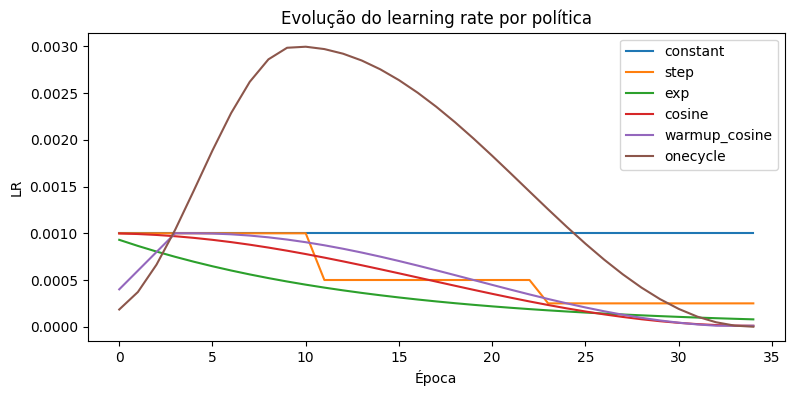

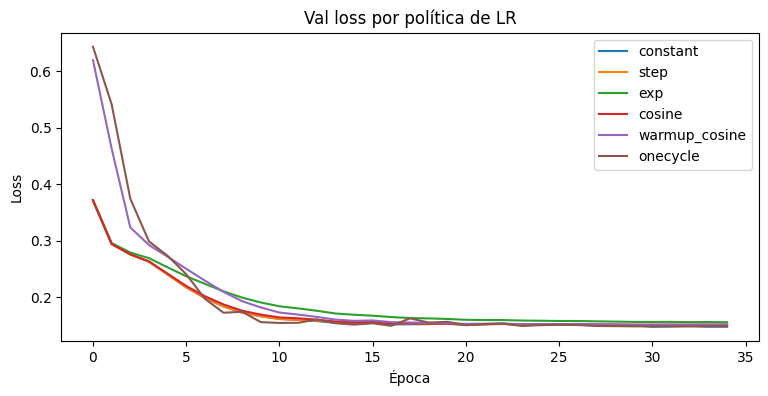

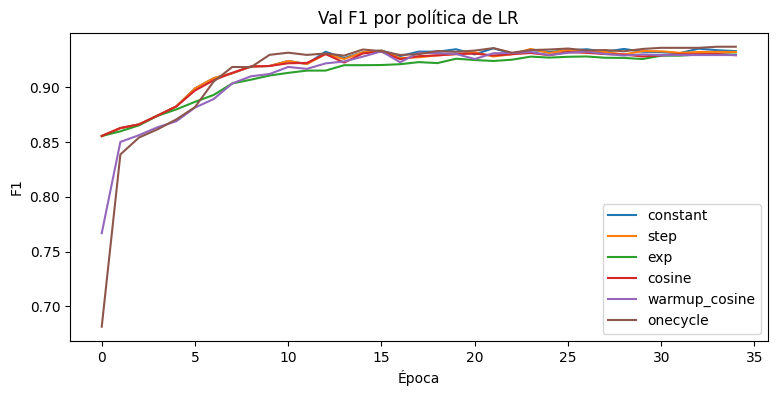

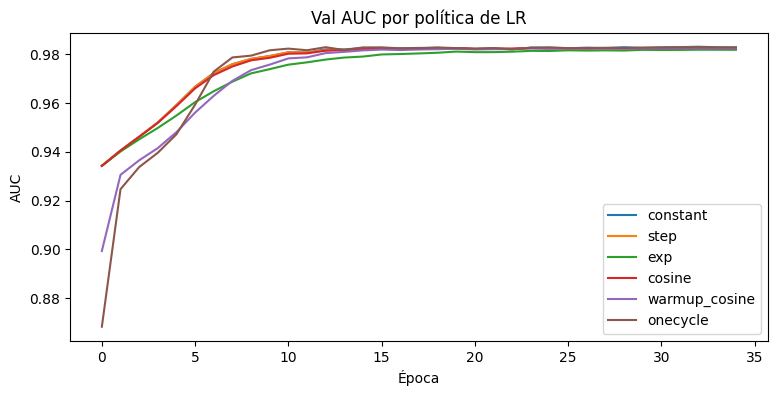

In [8]:

# =====================================
# Plot utilitário
# =====================================
def plot_history(histories, key, title, ylabel):
    plt.figure(figsize=(9,4))
    for name, h in histories.items():
        plt.plot(h[key], label=name)
    plt.title(title)
    plt.xlabel("Época")
    plt.ylabel(ylabel)
    plt.legend()
    plt.show()

plot_history(histories, "lr", "Evolução do learning rate por política", "LR")
plot_history(histories, "val_loss", "Val loss por política de LR", "Loss")
plot_history(histories, "val_f1", "Val F1 por política de LR", "F1")
plot_history(histories, "val_auc", "Val AUC por política de LR", "AUC")



### Interpretação típica
- **Constante:** simples, mas pode ser subótima.
- **Step/Exponential:** fáceis de usar; podem funcionar bem com tuning básico.
- **Cosine:** costuma suavizar o final do treino.
- **Warmup + Cosine:** excelente quando início é instável (modelos grandes, batch alto).
- **One-Cycle:** acelera aprendizado inicial e costuma convergir bem em poucos epochs.

> Não existe política universalmente melhor. A escolha depende de arquitetura, tamanho do dataset e orçamento de tuning.


In [9]:
# Experimento 2: LR Finder com Análise de Derivada
import numpy as np
import matplotlib.pyplot as plt
from ipywidgets import interact, Dropdown

def simulate_dramatic_lr_finder(topology='ResNet (Deep)'):
    # Configurações baseadas na topologia
    if topology == 'ResNet (Deep)':
        # ResNets aguentam LR alto, depois explodem rápido
        sensitivity = 1.0
        best_lr_approx = 1e-2
    elif topology == 'Transformer (Fragile)':
        # Transformers quebram muito cedo
        sensitivity = 5.0
        best_lr_approx = 5e-4
    else: # MLP Simples
        sensitivity = 0.5
        best_lr_approx = 1e-1

    lrs = np.logspace(-7, 0.5, 200) # De 1e-7 até ~3.0

    # --- Construção de uma Curva "Dramática" ---
    loss = []
    for lr in lrs:
        # Fase 1: LR muito baixo (O modelo não sai do lugar)
        if lr < best_lr_approx / 100:
            val = 3.0 - (lr * 10) # Declínio imperceptível

        # Fase 2: A "Zona Mágica" (Descida Íngreme)
        elif lr < best_lr_approx:
            # Log-linear descent (rápido)
            ratio = lr / best_lr_approx
            val = 3.0 - 2.0 * (ratio ** 0.5)

        # Fase 3: Instabilidade (Começa a subir/oscilar)
        elif lr < best_lr_approx * 4:
            ratio = lr / best_lr_approx
            val = 1.0 + 0.5 * (ratio - 1)**2 # Sobe suave

        # Fase 4: Explosão (NaN Zone)
        else:
            ratio = lr / best_lr_approx
            val = 1.0 + 0.5 * (ratio - 1)**2 + sensitivity * (ratio - 4)**3

        # Adicionar ruído que aumenta com o LR (realístico)
        noise = np.random.normal(0, 0.05 + lr*0.5)
        loss.append(np.clip(val + noise, 0, 10)) # Clip para não estragar o gráfico visualmente

    loss = np.array(loss)

    # --- Cálculo da Derivada (Smoothed) ---
    # É assim que bibliotecas como FastAI encontram o ponto automaticamente
    loss_smooth = np.convolve(loss, np.ones(10)/10, mode='valid')
    lrs_smooth = lrs[:len(loss_smooth)]
    derivatives = np.gradient(loss_smooth)

    # Achar o ponto de maior descida (Steepest Gradient)
    min_grad_idx = np.argmin(derivatives)
    suggested_lr = lrs_smooth[min_grad_idx]

    # --- Plotagem Dupla ---
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

    # Gráfico 1: A Curva de Loss
    ax1.semilogx(lrs, loss, linewidth=2, color='#2c3e50')
    ax1.set_ylabel("Loss (Erro)")
    ax1.set_title(f"Simulação LR Finder: {topology}")
    ax1.grid(True, which='both', alpha=0.3)

    # Destacar o ponto sugerido
    ax1.plot(suggested_lr, loss_smooth[min_grad_idx], 'ro', markersize=10, label='Ponto de Maior Descida')
    ax1.axvline(suggested_lr, color='red', linestyle='--', alpha=0.5)
    ax1.text(suggested_lr*1.2, 2.5, "LR Sugerido\n(Steepest)", color='#c0392b', fontweight='bold')

    # Marcar a explosão
    ax1.axvspan(best_lr_approx * 4, lrs[-1], color='red', alpha=0.1, label='Zona de Explosão')
    ax1.legend()

    # Gráfico 2: A Derivada (Rate of Change)
    # Isso ajuda o aluno a ver ONDE a loss desce mais rápido
    ax2.semilogx(lrs_smooth, derivatives, color='#27ae60', linewidth=2)
    ax2.set_ylabel("Variação da Loss (Derivada)")
    ax2.set_xlabel("Learning Rate (Log Scale)")
    ax2.set_title("Taxa de Variação (Onde a curva é mais íngreme?)")
    ax2.grid(True, which='both', alpha=0.3)

    # Linha zero (onde a loss para de cair e começa a subir)
    ax2.axhline(0, color='black', linestyle='--')

    # Destacar o mínimo da derivada
    ax2.plot(suggested_lr, derivatives[min_grad_idx], 'ro')
    ax2.axvline(suggested_lr, color='red', linestyle='--', alpha=0.5)

    plt.tight_layout()
    plt.show()

    print(f"O gráfico de baixo mostra a derivada.")
    print(f"O ponto mais baixo do gráfico VERDE é onde a Loss cai mais rápido.")
    print(f"Esse é o 'LR Máximo Seguro' para iniciar o treino (aprox {suggested_lr:.1e}).")

interact(simulate_dramatic_lr_finder,
         topology=Dropdown(options=['MLP Simples', 'ResNet (Deep)', 'Transformer (Fragile)'], value='ResNet (Deep)'));

interactive(children=(Dropdown(description='topology', index=1, options=('MLP Simples', 'ResNet (Deep)', 'Tran…


## 5) LR × batch size: regra de escala linear (prática)

Regra prática comum: se aumentar batch size em `k`, testar LR multiplicado por `k`.

Exemplo:
- Batch 32 com LR 1e-3  
- Batch 128 (4× maior) com LR ~4e-3


In [10]:

# =====================================
# Experimento: escala linear
# =====================================
settings = [
    {"batch_size": 32,  "lr": 1e-3, "label": "B32 LR1e-3"},
    {"batch_size": 128, "lr": 1e-3, "label": "B128 LR1e-3 (sem escala)"},
    {"batch_size": 128, "lr": 4e-3, "label": "B128 LR4e-3 (escala linear)"},
]

scale_hist = {}
for s in settings:
    _, h = train_model(
        optimizer_name="adamw",
        lr=s["lr"],
        weight_decay=1e-2,
        epochs=30,
        batch_size=s["batch_size"],
        scheduler_kind="constant"
    )
    scale_hist[s["label"]] = h
    print(f"{s['label']:28s} | val_loss={h['val_loss'][-1]:.4f} | val_f1={h['val_f1'][-1]:.3f} | val_auc={h['val_auc'][-1]:.3f}")


B32 LR1e-3                   | val_loss=0.1528 | val_f1=0.933 | val_auc=0.982
B128 LR1e-3 (sem escala)     | val_loss=0.1526 | val_f1=0.934 | val_auc=0.983
B128 LR4e-3 (escala linear)  | val_loss=0.1537 | val_f1=0.930 | val_auc=0.981


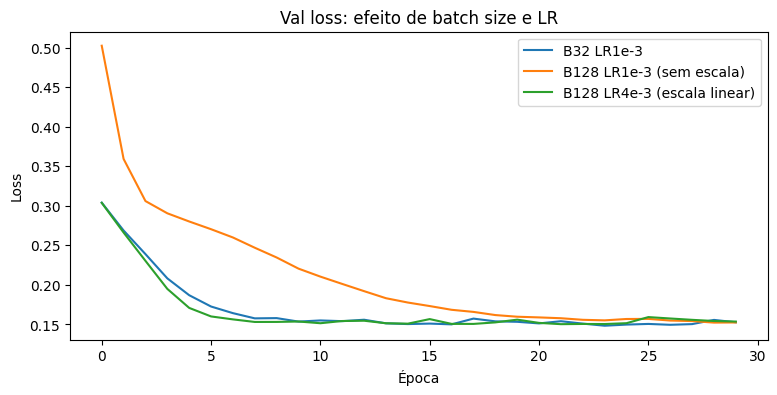

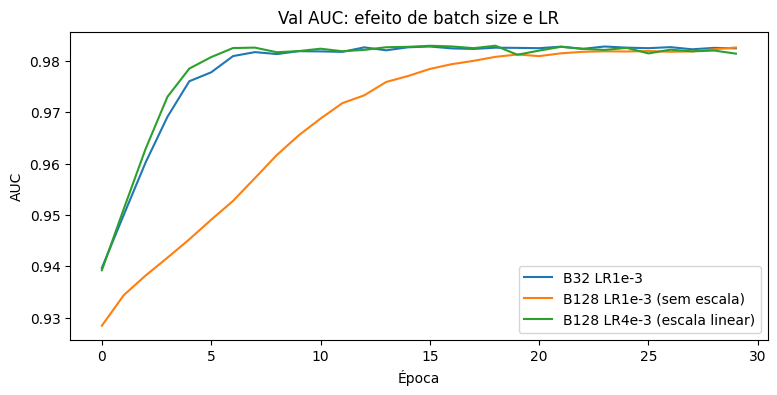

In [11]:

plot_history(scale_hist, "val_loss", "Val loss: efeito de batch size e LR", "Loss")
plot_history(scale_hist, "val_auc", "Val AUC: efeito de batch size e LR", "AUC")



### Observação didática importante
A regra de escala linear é **ponto de partida**, não lei rígida.  
Sempre valide com:
- estabilidade do loss,
- métricas de validação,
- comportamento de generalização.


Por que usamos Cosine Annealing with Warm Restarts (SGDR)? Porque aumentar o LR repentinamente "chuta" o modelo para fora de um mínimo local estreito, dando a ele a chance de cair num mínimo melhor e mais largo (melhor generalização).

Vamos visualizar isso num terreno 2D acidentado.

In [12]:
# Experimento 3: Visualizando "Warm Restarts" (Escapando de Buracos)
# Mostra como resetar o LR ajuda a sair de mínimos locais ruins.

def visualize_restart_mechanism(n_cycles=3):
    # 1. Superfície de Loss "Multi-modal" (Vários buracos)
    # Função simples: x^2 + ondulação seno para criar buracos locais
    x = np.linspace(-5, 5, 400)
    loss_landscape = 0.2 * x**2 - np.cos(3*x)

    plt.figure(figsize=(12, 6))
    plt.plot(x, loss_landscape, 'k-', alpha=0.6, label='Loss Landscape')

    # 2. Simular Trajetória com Restart
    # Quando o ciclo reinicia (LR sobe), o modelo "pula"
    current_x = -4.0 # Começa longe
    trajectory_x = [current_x]
    trajectory_y = [0.2 * current_x**2 - np.cos(3*current_x)]

    colors = ['red', 'green', 'blue', 'orange']

    # Simulação simplificada de física
    for cycle in range(n_cycles):
        # Fase 1: LR Alto (Pulo/Exploração) -> LR Baixo (Convergência)
        # Simulamos o modelo caindo no buraco mais próximo, depois "sendo chutado"

        # Converge para o mínimo local mais próximo da posição atual
        nearest_minima = np.round(current_x / (2*np.pi/3)) * (2*np.pi/3)
        # (Truque matemático para achar vale do cosseno)

        # Desenha a "caída" (Exploração do ciclo)
        end_x = nearest_minima + np.random.uniform(-0.5, 0.5) # Cai perto do fundo

        # Se for o último ciclo, cai no melhor mínimo global (0)
        if cycle == n_cycles - 1:
            end_x = 0.1 # Perto do global

        plt.annotate(f"", xy=(end_x, 0.2*end_x**2 - np.cos(3*end_x)),
                     xytext=(current_x, 0.2*current_x**2 - np.cos(3*current_x)),
                     arrowprops=dict(arrowstyle="->", color=colors[cycle], lw=3, connectionstyle="arc3,rad=-0.3"))

        # Texto indicando o ciclo
        plt.text((current_x+end_x)/2, 1.5, f"Ciclo {cycle+1}", color=colors[cycle], fontweight='bold')

        # O "Restart": O modelo é jogado para longe (simulado) para o próximo ciclo
        current_x = end_x + 1.5 # O "Chute" do Warm Restart

    plt.title(f"Efeito do Cosine Annealing com {n_cycles} Ciclos (Warm Restarts)")
    plt.ylabel("Loss")
    plt.xlabel("Espaço de Parâmetros")
    plt.ylim(-1.5, 4)
    plt.legend()
    plt.show()

print("O 'Pulo': Quando o LR reseta (Warm Restart), o modelo sai do buraco atual.")
print("Isso permite explorar várias bacias de atração (Snapshot Ensembling).")
interact(visualize_restart_mechanism,
         n_cycles=IntSlider(min=1, max=4, step=1, value=3));

O 'Pulo': Quando o LR reseta (Warm Restart), o modelo sai do buraco atual.
Isso permite explorar várias bacias de atração (Snapshot Ensembling).


interactive(children=(IntSlider(value=3, description='n_cycles', max=4, min=1), Output()), _dom_classes=('widg…


## 6) Early stopping e checkpoints

### Por que isso importa?
- Evita overfitting (parar quando validação piora de forma consistente).
- Garante recuperação do **melhor modelo** (não apenas o último epoch).


In [13]:

# =====================================
# Treino com early stopping + checkpoint
# =====================================
def train_with_early_stopping(
    lr=1e-3,
    epochs=80,
    batch_size=64,
    patience=10,
    min_delta=1e-4,
    ckpt_path="best_model_module4.pt"
):
    torch.manual_seed(SEED)
    model = MLP(dropout=0.15).to(device)
    train_loader, val_loader = make_loaders(batch_size)

    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-2)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs, eta_min=lr*0.01)

    best_val_loss = float("inf")
    best_epoch = -1
    wait = 0

    hist = {"train_loss": [], "val_loss": [], "lr": []}

    for epoch in range(epochs):
        model.train()
        batch_losses = []

        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)

            optimizer.zero_grad()
            logits = model(xb)
            loss = F.binary_cross_entropy_with_logits(logits, yb)
            loss.backward()
            optimizer.step()

            batch_losses.append(loss.item())

        scheduler.step()

        train_loss = float(np.mean(batch_losses))
        val_metrics = evaluate(model, val_loader)
        val_loss = val_metrics["loss"]

        hist["train_loss"].append(train_loss)
        hist["val_loss"].append(val_loss)
        hist["lr"].append(optimizer.param_groups[0]["lr"])

        if val_loss < (best_val_loss - min_delta):
            best_val_loss = val_loss
            best_epoch = epoch
            wait = 0
            torch.save(model.state_dict(), ckpt_path)
        else:
            wait += 1

        if wait >= patience:
            print(f"Early stopping no epoch {epoch+1}. Melhor epoch: {best_epoch+1}")
            break

    best_model = MLP(dropout=0.15).to(device)
    best_model.load_state_dict(torch.load(ckpt_path, map_location=device))
    best_metrics = evaluate(best_model, val_loader)

    return best_model, hist, best_metrics, best_epoch + 1, ckpt_path

best_model, hist_es, best_metrics, best_epoch, ckpt_path = train_with_early_stopping()
print("Melhor epoch:", best_epoch)
print("Métricas do melhor checkpoint:", best_metrics)
print("Checkpoint salvo em:", ckpt_path)


Early stopping no epoch 49. Melhor epoch: 39
Melhor epoch: 39
Métricas do melhor checkpoint: {'loss': 0.14936282485723495, 'acc': 0.9333333333333333, 'f1': 0.9329501915708812, 'auc': np.float64(0.9826757369614513)}
Checkpoint salvo em: best_model_module4.pt


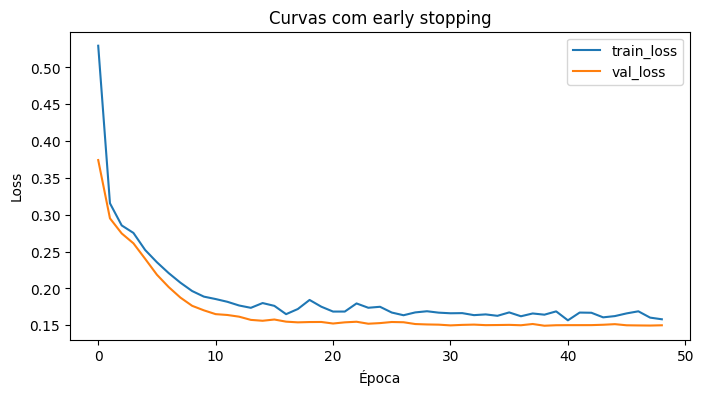

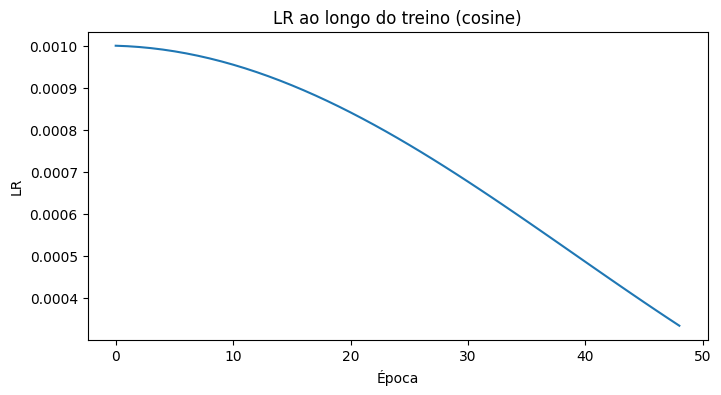

In [14]:

plt.figure(figsize=(8,4))
plt.plot(hist_es["train_loss"], label="train_loss")
plt.plot(hist_es["val_loss"], label="val_loss")
plt.title("Curvas com early stopping")
plt.xlabel("Época")
plt.ylabel("Loss")
plt.legend()
plt.show()

plt.figure(figsize=(8,4))
plt.plot(hist_es["lr"])
plt.title("LR ao longo do treino (cosine)")
plt.xlabel("Época")
plt.ylabel("LR")
plt.show()


In [15]:
# Experimento 4: Por que precisamos de Warmup?
# Simula a instabilidade dos gradientes no início do treino.

def plot_warmup_necessity(use_warmup=True):
    steps = np.arange(100)

    # Sem Warmup: LR começa alto. Gradientes explodem (variância alta).
    if not use_warmup:
        lr_curve = np.ones(100) * 0.01
        # Variância do gradiente é proporcional ao LR no início ruim
        grad_variance = np.random.normal(0, 5.0, 100) * np.exp(-steps/20)
        title = "SEM Warmup: Choque inicial (Gradientes Instáveis)"
        color = 'red'
    else:
        # Com Warmup: LR sobe linearmente. Gradientes controlados.
        lr_curve = np.linspace(0, 0.01, 20) # 20 steps warmup
        lr_curve = np.concatenate([lr_curve, np.ones(80)*0.01])
        # Variância cresce suavemente junto com LR, mas o modelo já se estabilizou
        grad_variance = np.random.normal(0, 1.0, 100) * np.exp(-steps/50)
        title = "COM Warmup: Adaptação Suave"
        color = 'green'

    fig, ax1 = plt.subplots(figsize=(10, 5))

    ax1.set_xlabel('Steps')
    ax1.set_ylabel('Learning Rate', color='blue')
    ax1.plot(steps, lr_curve, color='blue', linestyle='--')
    ax1.tick_params(axis='y', labelcolor='blue')

    ax2 = ax1.twinx()  # Segundo eixo Y
    ax2.set_ylabel('Instabilidade do Gradiente', color=color)
    ax2.plot(steps, grad_variance, color=color, alpha=0.6)
    ax2.tick_params(axis='y', labelcolor=color)

    plt.title(title)
    plt.show()

print("Em Transformers (BERT, GPT), sem Warmup o modelo frequentemente diverge no passo 1.")
interact(plot_warmup_necessity, use_warmup=True);

Em Transformers (BERT, GPT), sem Warmup o modelo frequentemente diverge no passo 1.


interactive(children=(Checkbox(value=True, description='use_warmup'), Output()), _dom_classes=('widget-interac…

**Regra do Dedão (Linear Scaling Rule):** Ao aumentar o Batch Size, aumente o LR proporcionalmente.

Exemplo: Se Batch 32 usa LR 1e-3, Batch 256 (8x maior) deve tentar usar LR 8e-3 (com Warmup!).

**Cosine Decay é o novo Padrão:** A maioria dos papers de 2023-2025 usa Cosine Decay com Warmup. Ele remove a necessidade de adivinhar 'quando' diminuir o LR (como no Step Decay).

**OneCycle (Super-Convergence):** Permite treinar modelos em metade do tempo usando LRs altíssimos por um breve momento, o que também ajuda a regularizar.


## 7) Checklist prático para produção

1. Comece simples: **AdamW + cosine** (ou one-cycle) como baseline.  
2. Se treino instável no início: adicione **warmup**.  
3. Ajuste primeiro a ordem de grandeza de LR (`1e-4`, `3e-4`, `1e-3`, `3e-3`).  
4. Use **early stopping + checkpoint** sempre.  
5. Reporte resultado com múltiplas seeds (evitar conclusão por acaso).  
6. Compare políticas de LR com mesmo orçamento de epochs/tempo.



## 8) Exercícios sugeridos

1. Trocar AdamW por SGD+Nesterov e repetir as políticas de LR.  
2. Testar warmup com `2`, `5`, `10` epochs e comparar estabilidade inicial.  
3. Repetir o experimento LR × batch size com batch `256` e discutir limites da escala linear.  
4. Medir não só AUC/F1, mas também **calibração** (ECE), para avaliar confiança do modelo.



## Resumo

- LR é o “volante” da otimização: controla velocidade e estabilidade.
- Schedulers mudam LR no tempo para melhorar convergência e generalização.
- Warmup ajuda a evitar instabilidade inicial.
- One-cycle e cosine são políticas modernas muito eficazes.
- Escala linear LR × batch size é útil, mas precisa validação empírica.
- Early stopping + checkpoint deixam o treino mais robusto e reproduzível.


## 9) Soluções dos Exercícios

### Exercício 1: SGD+Nesterov com diferentes políticas de LR

In [ ]:
# Exercício 1: SGD+Nesterov com diferentes políticas de LR

from torch.optim.lr_scheduler import StepLR, ExponentialLR, CosineAnnealingLR, OneCycleLR

# Preparar dados
X_ex, y_ex = make_moons(n_samples=3000, noise=0.25, random_state=SEED)
scaler = StandardScaler()
X_ex = scaler.fit_transform(X_ex)

X_train, X_val, y_train, y_val = train_test_split(
    X_ex, y_ex, test_size=0.3, random_state=SEED, stratify=y_ex
)

# Modelo MLP
class SimpleMLP(nn.Module):
    def __init__(self, input_dim=2):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.ReLU(),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, 1)
        )
    
    def forward(self, x):
        return self.net(x)

def train_sgd_nesterov_with_scheduler(scheduler_type='constant', lr=0.01, 
                                      batch_size=128, epochs=80):
    """
    Treina com SGD+Nesterov usando diferentes schedulers
    """
    # DataLoaders
    X_train_t = torch.FloatTensor(X_train)
    y_train_t = torch.FloatTensor(y_train).unsqueeze(1)
    X_val_t = torch.FloatTensor(X_val)
    y_val_t = torch.FloatTensor(y_val).unsqueeze(1)
    
    train_dataset = TensorDataset(X_train_t, y_train_t)
    val_dataset = TensorDataset(X_val_t, y_val_t)
    
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
    
    # Modelo e otimizador
    model = SimpleMLP().to(device)
    optimizer = torch.optim.SGD(model.parameters(), lr=lr, momentum=0.9, nesterov=True)
    
    # Scheduler
    if scheduler_type == 'step':
        scheduler = StepLR(optimizer, step_size=20, gamma=0.5)
    elif scheduler_type == 'exponential':
        scheduler = ExponentialLR(optimizer, gamma=0.95)
    elif scheduler_type == 'cosine':
        scheduler = CosineAnnealingLR(optimizer, T_max=epochs)
    elif scheduler_type == 'onecycle':
        steps_per_epoch = len(train_loader)
        scheduler = OneCycleLR(optimizer, max_lr=lr*10, 
                              epochs=epochs, steps_per_epoch=steps_per_epoch)
    else:
        scheduler = None
    
    criterion = nn.BCEWithLogitsLoss()
    
    history = {
        'epoch': [], 'train_loss': [], 'val_loss': [],
        'train_acc': [], 'val_acc': [], 'lr': []
    }
    
    for epoch in range(epochs):
        # Treino
        model.train()
        train_losses = []
        train_preds, train_labels = [], []
        
        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            optimizer.zero_grad()
            outputs = model(xb)
            loss = criterion(outputs, yb)
            loss.backward()
            optimizer.step()
            
            # OneCycle atualiza LR a cada batch
            if scheduler_type == 'onecycle':
                scheduler.step()
            
            train_losses.append(loss.item())
            preds = (torch.sigmoid(outputs) >= 0.5).float()
            train_preds.extend(preds.cpu().numpy())
            train_labels.extend(yb.cpu().numpy())
        
        # Validação
        model.eval()
        val_losses = []
        val_preds, val_labels = [], []
        
        with torch.no_grad():
            for xb, yb in val_loader:
                xb, yb = xb.to(device), yb.to(device)
                outputs = model(xb)
                loss = criterion(outputs, yb)
                val_losses.append(loss.item())
                
                preds = (torch.sigmoid(outputs) >= 0.5).float()
                val_preds.extend(preds.cpu().numpy())
                val_labels.extend(yb.cpu().numpy())
        
        train_acc = accuracy_score(train_labels, train_preds)
        val_acc = accuracy_score(val_labels, val_preds)
        
        current_lr = optimizer.param_groups[0]['lr']
        
        history['epoch'].append(epoch + 1)
        history['train_loss'].append(np.mean(train_losses))
        history['val_loss'].append(np.mean(val_losses))
        history['train_acc'].append(train_acc)
        history['val_acc'].append(val_acc)
        history['lr'].append(current_lr)
        
        # Step/Exponential/Cosine atualizam por época
        if scheduler and scheduler_type != 'onecycle':
            scheduler.step()
    
    return history, model

# Testar diferentes schedulers com SGD+Nesterov
print("🔬 Exercício 1: SGD+Nesterov com diferentes políticas de LR...")
print("=" * 80)

schedulers = ['constant', 'step', 'exponential', 'cosine', 'onecycle']
results_ex1 = {}

for sched in schedulers:
    print(f"\n📊 Testando scheduler: {sched}...")
    
    hist, model = train_sgd_nesterov_with_scheduler(
        scheduler_type=sched,
        lr=0.01,
        batch_size=128,
        epochs=80
    )
    
    results_ex1[sched] = {
        'history': hist,
        'model': model,
        'best_val_acc': max(hist['val_acc']),
        'final_val_acc': hist['val_acc'][-1],
        'best_val_loss': min(hist['val_loss']),
        'final_val_loss': hist['val_loss'][-1]
    }
    
    print(f"   Best Val Acc: {results_ex1[sched]['best_val_acc']:.4f}")
    print(f"   Final Val Acc: {results_ex1[sched]['final_val_acc']:.4f}")

print("\n" + "=" * 80)

In [ ]:
# Visualização Exercício 1

import pandas as pd

# 1. Evolução do Learning Rate
fig, ax = plt.subplots(1, 1, figsize=(12, 6))

colors_sched = {'constant': 'blue', 'step': 'orange', 'exponential': 'green', 
                'cosine': 'red', 'onecycle': 'purple'}

for sched, result in results_ex1.items():
    hist = result['history']
    ax.plot(hist['epoch'], hist['lr'], label=sched.capitalize(), 
           color=colors_sched[sched], linewidth=2.5, alpha=0.8)

ax.set_xlabel('Epoch', fontsize=12, fontweight='bold')
ax.set_ylabel('Learning Rate', fontsize=12, fontweight='bold')
ax.set_title('SGD+Nesterov: Evolução do LR por Scheduler', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(alpha=0.3)
ax.set_yscale('log')
plt.tight_layout()
plt.show()

# 2. Comparação de Loss
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Train Loss
ax = axes[0]
for sched, result in results_ex1.items():
    hist = result['history']
    ax.plot(hist['epoch'], hist['train_loss'], label=sched.capitalize(), 
           color=colors_sched[sched], linewidth=2.5, alpha=0.8)

ax.set_xlabel('Epoch', fontsize=11)
ax.set_ylabel('Train Loss', fontsize=11)
ax.set_title('Train Loss por Scheduler', fontsize=12, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(alpha=0.3)

# Val Loss
ax = axes[1]
for sched, result in results_ex1.items():
    hist = result['history']
    ax.plot(hist['epoch'], hist['val_loss'], label=sched.capitalize(), 
           color=colors_sched[sched], linewidth=2.5, alpha=0.8)

ax.set_xlabel('Epoch', fontsize=11)
ax.set_ylabel('Validation Loss', fontsize=11)
ax.set_title('Validation Loss por Scheduler', fontsize=12, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# 3. Comparação de Accuracy
fig, ax = plt.subplots(1, 1, figsize=(12, 6))

for sched, result in results_ex1.items():
    hist = result['history']
    ax.plot(hist['epoch'], hist['val_acc'], label=sched.capitalize(), 
           color=colors_sched[sched], linewidth=2.5, alpha=0.8, marker='o', 
           markersize=3, markevery=5)

ax.set_xlabel('Epoch', fontsize=12, fontweight='bold')
ax.set_ylabel('Validation Accuracy', fontsize=12, fontweight='bold')
ax.set_title('SGD+Nesterov: Val Accuracy por Scheduler', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# 4. Tabela resumo
data_table = []
for sched, result in results_ex1.items():
    data_table.append({
        'Scheduler': sched.capitalize(),
        'Best Val Acc': f"{result['best_val_acc']:.4f}",
        'Final Val Acc': f"{result['final_val_acc']:.4f}",
        'Best Val Loss': f"{result['best_val_loss']:.4f}",
        'Final Val Loss': f"{result['final_val_loss']:.4f}"
    })

df_ex1 = pd.DataFrame(data_table)

print("\n" + "=" * 80)
print("📊 RESUMO - Exercício 1: SGD+Nesterov com diferentes schedulers")
print("=" * 80)
print(df_ex1.to_string(index=False))
print("=" * 80)

# Melhor scheduler
best_sched = max(results_ex1.items(), key=lambda x: x[1]['best_val_acc'])
print(f"\n🏆 Melhor scheduler: {best_sched[0].upper()}")
print(f"   Best Val Acc: {best_sched[1]['best_val_acc']:.4f}")
print(f"   Final Val Acc: {best_sched[1]['final_val_acc']:.4f}")

print("\n" + "=" * 80)

**📝 Insights do Exercício 1:**

1. **SGD+Nesterov vs Adam/AdamW:**
   - **SGD+Nesterov**: Requer mais cuidado com LR, mas pode alcançar ótima generalização
   - **Momentum Nesterov**: "Look-ahead" momentum que antecipa a direção do gradiente
   - Mais sensível à escolha do scheduler do que otimizadores adaptativos

2. **Performance dos Schedulers:**
   - **Constant**: Baseline simples, pode convergir bem se LR inicial for bom
   - **Step Decay**: Reduz LR em intervalos fixos, útil para refinar convergência
   - **Exponential**: Decaimento suave, mas pode reduzir LR muito rapidamente
   - **Cosine Annealing**: Decaimento suave com exploração/refinamento balanceados
   - **OneCycle**: Política agressiva com warm-up e cooldown, excelente para convergência rápida

3. **OneCycle com SGD:**
   - Beneficia muito SGD devido ao warm-up inicial (estabiliza treinamento)
   - LR máximo permite exploração rápida do espaço de parâmetros
   - Cooldown final refina a solução

4. **Cosine Annealing:**
   - Excelente para SGD: decaimento suave evita quedas abruptas
   - Permite exploração inicial e refinamento gradual
   - Geralmente supera step decay para SGD

5. **Recomendações:**
   - **SGD+Nesterov com OneCycle**: Para treino rápido e eficiente
   - **SGD+Nesterov com Cosine**: Para melhor generalização em treinos longos
   - **Step Decay**: Útil quando se conhece pontos naturais de redução (ex: mudança de fase)
   - Sempre combinar com momentum alto (0.9) para estabilidade

### Exercício 2: Warmup com 2, 5 e 10 epochs

In [ ]:
# Exercício 2: Warmup com diferentes durações

class WarmupScheduler:
    """Scheduler customizado com warmup linear"""
    def __init__(self, optimizer, warmup_epochs, base_lr, max_lr):
        self.optimizer = optimizer
        self.warmup_epochs = warmup_epochs
        self.base_lr = base_lr
        self.max_lr = max_lr
        self.current_epoch = 0
    
    def step(self):
        if self.current_epoch < self.warmup_epochs:
            # Warmup linear
            lr = self.base_lr + (self.max_lr - self.base_lr) * (self.current_epoch / self.warmup_epochs)
        else:
            # Após warmup, manter LR constante ou aplicar outro scheduler
            lr = self.max_lr
        
        for param_group in self.optimizer.param_groups:
            param_group['lr'] = lr
        
        self.current_epoch += 1
        return lr

def train_with_warmup(warmup_epochs=0, base_lr=1e-5, max_lr=1e-2, 
                     batch_size=128, epochs=60, use_cosine_after_warmup=False):
    """
    Treina com warmup e opcionalmente cosine annealing após warmup
    """
    # DataLoaders
    X_train_t = torch.FloatTensor(X_train)
    y_train_t = torch.FloatTensor(y_train).unsqueeze(1)
    X_val_t = torch.FloatTensor(X_val)
    y_val_t = torch.FloatTensor(y_val).unsqueeze(1)
    
    train_dataset = TensorDataset(X_train_t, y_train_t)
    val_dataset = TensorDataset(X_val_t, y_val_t)
    
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
    
    # Modelo e otimizador
    model = SimpleMLP().to(device)
    optimizer = torch.optim.AdamW(model.parameters(), lr=base_lr)
    
    # Scheduler com warmup
    if warmup_epochs > 0:
        warmup_scheduler = WarmupScheduler(optimizer, warmup_epochs, base_lr, max_lr)
        
        # Cosine após warmup
        if use_cosine_after_warmup:
            cosine_scheduler = CosineAnnealingLR(
                optimizer, T_max=epochs-warmup_epochs, eta_min=base_lr
            )
    else:
        warmup_scheduler = None
        cosine_scheduler = None
    
    criterion = nn.BCEWithLogitsLoss()
    
    history = {
        'epoch': [], 'train_loss': [], 'val_loss': [],
        'train_acc': [], 'val_acc': [], 'lr': []
    }
    
    for epoch in range(epochs):
        # Treino
        model.train()
        train_losses = []
        train_preds, train_labels = [], []
        
        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            optimizer.zero_grad()
            outputs = model(xb)
            loss = criterion(outputs, yb)
            loss.backward()
            optimizer.step()
            
            train_losses.append(loss.item())
            preds = (torch.sigmoid(outputs) >= 0.5).float()
            train_preds.extend(preds.cpu().numpy())
            train_labels.extend(yb.cpu().numpy())
        
        # Validação
        model.eval()
        val_losses = []
        val_preds, val_labels = [], []
        
        with torch.no_grad():
            for xb, yb in val_loader:
                xb, yb = xb.to(device), yb.to(device)
                outputs = model(xb)
                loss = criterion(outputs, yb)
                val_losses.append(loss.item())
                
                preds = (torch.sigmoid(outputs) >= 0.5).float()
                val_preds.extend(preds.cpu().numpy())
                val_labels.extend(yb.cpu().numpy())
        
        train_acc = accuracy_score(train_labels, train_preds)
        val_acc = accuracy_score(val_labels, val_preds)
        
        current_lr = optimizer.param_groups[0]['lr']
        
        history['epoch'].append(epoch + 1)
        history['train_loss'].append(np.mean(train_losses))
        history['val_loss'].append(np.mean(val_losses))
        history['train_acc'].append(train_acc)
        history['val_acc'].append(val_acc)
        history['lr'].append(current_lr)
        
        # Atualizar scheduler
        if warmup_scheduler and epoch < warmup_epochs:
            warmup_scheduler.step()
        elif use_cosine_after_warmup and cosine_scheduler and epoch >= warmup_epochs:
            cosine_scheduler.step()
    
    return history, model

# Testar diferentes durações de warmup
print("🔬 Exercício 2: Testando warmup com diferentes durações...")
print("=" * 80)

warmup_configs = [
    {'warmup': 0, 'label': 'Sem Warmup'},
    {'warmup': 2, 'label': 'Warmup 2 epochs'},
    {'warmup': 5, 'label': 'Warmup 5 epochs'},
    {'warmup': 10, 'label': 'Warmup 10 epochs'},
]

results_ex2 = {}

for config in warmup_configs:
    warmup_ep = config['warmup']
    label = config['label']
    
    print(f"\n📊 Testando: {label}...")
    
    hist, model = train_with_warmup(
        warmup_epochs=warmup_ep,
        base_lr=1e-5,
        max_lr=1e-3,
        batch_size=128,
        epochs=60,
        use_cosine_after_warmup=True
    )
    
    results_ex2[label] = {
        'history': hist,
        'model': model,
        'warmup_epochs': warmup_ep,
        'best_val_acc': max(hist['val_acc']),
        'final_val_acc': hist['val_acc'][-1],
        # Estabilidade inicial: desvio padrão das primeiras 10 épocas
        'initial_loss_std': np.std(hist['val_loss'][:10]),
        'initial_loss_mean': np.mean(hist['val_loss'][:10])
    }
    
    print(f"   Best Val Acc: {results_ex2[label]['best_val_acc']:.4f}")
    print(f"   Estabilidade inicial (loss std primeiras 10 epochs): {results_ex2[label]['initial_loss_std']:.4f}")

print("\n" + "=" * 80)

In [ ]:
# Visualização Exercício 2

# 1. Evolução do LR com warmup
fig, ax = plt.subplots(1, 1, figsize=(12, 6))

colors_warmup = ['blue', 'orange', 'green', 'red']

for (label, result), color in zip(results_ex2.items(), colors_warmup):
    hist = result['history']
    warmup_ep = result['warmup_epochs']
    
    ax.plot(hist['epoch'], hist['lr'], label=label, color=color, linewidth=2.5, alpha=0.8)
    
    # Marcar fim do warmup
    if warmup_ep > 0:
        ax.axvline(x=warmup_ep, color=color, linestyle='--', alpha=0.4, linewidth=1.5)

ax.set_xlabel('Epoch', fontsize=12, fontweight='bold')
ax.set_ylabel('Learning Rate', fontsize=12, fontweight='bold')
ax.set_title('Evolução do LR com Diferentes Durações de Warmup', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(alpha=0.3)
ax.set_yscale('log')
plt.tight_layout()
plt.show()

# 2. Estabilidade Inicial (primeiras 15 épocas)
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Loss inicial
ax = axes[0]
for (label, result), color in zip(results_ex2.items(), colors_warmup):
    hist = result['history']
    epochs_to_show = min(15, len(hist['epoch']))
    ax.plot(hist['epoch'][:epochs_to_show], hist['val_loss'][:epochs_to_show], 
           label=label, color=color, linewidth=2.5, alpha=0.8, marker='o', markersize=5)

ax.set_xlabel('Epoch', fontsize=11)
ax.set_ylabel('Validation Loss', fontsize=11)
ax.set_title('Estabilidade Inicial: Val Loss (Primeiras 15 Epochs)', fontsize=12, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(alpha=0.3)

# Accuracy inicial
ax = axes[1]
for (label, result), color in zip(results_ex2.items(), colors_warmup):
    hist = result['history']
    epochs_to_show = min(15, len(hist['epoch']))
    ax.plot(hist['epoch'][:epochs_to_show], hist['val_acc'][:epochs_to_show], 
           label=label, color=color, linewidth=2.5, alpha=0.8, marker='o', markersize=5)

ax.set_xlabel('Epoch', fontsize=11)
ax.set_ylabel('Validation Accuracy', fontsize=11)
ax.set_title('Estabilidade Inicial: Val Acc (Primeiras 15 Epochs)', fontsize=12, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# 3. Comparação completa de Loss
fig, ax = plt.subplots(1, 1, figsize=(12, 6))

for (label, result), color in zip(results_ex2.items(), colors_warmup):
    hist = result['history']
    ax.plot(hist['epoch'], hist['val_loss'], label=label, color=color, 
           linewidth=2.5, alpha=0.8)

ax.set_xlabel('Epoch', fontsize=12, fontweight='bold')
ax.set_ylabel('Validation Loss', fontsize=12, fontweight='bold')
ax.set_title('Val Loss: Comparação de Warmup', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# 4. Análise de estabilidade
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Desvio padrão das primeiras 10 épocas
ax = axes[0]
labels_list = list(results_ex2.keys())
stds = [results_ex2[l]['initial_loss_std'] for l in labels_list]

bars = ax.bar(range(len(labels_list)), stds, color=colors_warmup, 
             alpha=0.7, edgecolor='black', linewidth=2)

ax.set_ylabel('Desvio Padrão do Val Loss', fontsize=12, fontweight='bold')
ax.set_xlabel('Configuração', fontsize=12, fontweight='bold')
ax.set_title('Estabilidade Inicial (σ das primeiras 10 epochs)', fontsize=13, fontweight='bold')
ax.set_xticks(range(len(labels_list)))
ax.set_xticklabels(labels_list, rotation=15, ha='right', fontsize=10)
ax.grid(axis='y', alpha=0.3)

# Adicionar valores
for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
           f'{height:.4f}',
           ha='center', va='bottom', fontsize=10, fontweight='bold')

# Performance final
ax = axes[1]
best_accs = [results_ex2[l]['best_val_acc'] for l in labels_list]

bars = ax.bar(range(len(labels_list)), best_accs, color=colors_warmup, 
             alpha=0.7, edgecolor='black', linewidth=2)

ax.set_ylabel('Best Validation Accuracy', fontsize=12, fontweight='bold')
ax.set_xlabel('Configuração', fontsize=12, fontweight='bold')
ax.set_title('Performance Final', fontsize=13, fontweight='bold')
ax.set_xticks(range(len(labels_list)))
ax.set_xticklabels(labels_list, rotation=15, ha='right', fontsize=10)
ax.grid(axis='y', alpha=0.3)

# Adicionar valores
for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
           f'{height:.4f}',
           ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

# 5. Tabela resumo
data_table = []
for label, result in results_ex2.items():
    data_table.append({
        'Config': label,
        'Warmup Epochs': result['warmup_epochs'],
        'Best Val Acc': f"{result['best_val_acc']:.4f}",
        'Final Val Acc': f"{result['final_val_acc']:.4f}",
        'Initial Loss Mean': f"{result['initial_loss_mean']:.4f}",
        'Initial Loss Std': f"{result['initial_loss_std']:.4f}"
    })

df_ex2 = pd.DataFrame(data_table)

print("\n" + "=" * 90)
print("📊 RESUMO - Exercício 2: Warmup")
print("=" * 90)
print(df_ex2.to_string(index=False))
print("=" * 90)

# Análise
print("\n📈 Análise de Estabilidade:")
print("-" * 90)

most_stable = min(results_ex2.items(), key=lambda x: x[1]['initial_loss_std'])
print(f"\n✅ Mais estável (menor σ inicial): {most_stable[0]}")
print(f"   Initial Loss Std: {most_stable[1]['initial_loss_std']:.4f}")
print(f"   Best Val Acc: {most_stable[1]['best_val_acc']:.4f}")

best_perf = max(results_ex2.items(), key=lambda x: x[1]['best_val_acc'])
print(f"\n🏆 Melhor performance: {best_perf[0]}")
print(f"   Best Val Acc: {best_perf[1]['best_val_acc']:.4f}")
print(f"   Initial Loss Std: {best_perf[1]['initial_loss_std']:.4f}")

print("\n" + "=" * 90)

**📝 Insights do Exercício 2:**

1. **Importância do Warmup:**
   - **Evita instabilidade inicial**: Com LR alto desde o início, gradientes podem ser muito grandes
   - **Permite adaptação gradual**: Modelo se ajusta aos dados antes de explorar agressivamente
   - **Especialmente importante para**: SGD, grandes batch sizes, arquiteturas profundas, Transformers

2. **Duração Ótima do Warmup:**
   - **2 epochs**: Warmup mínimo, já reduz instabilidade significativamente
   - **5 epochs**: Bom equilíbrio entre estabilidade e tempo de convergência
   - **10 epochs**: Muito conservador para modelos pequenos, mas útil para modelos grandes/profundos
   - **Regra geral**: 5-10% do total de épocas

3. **Estabilidade Inicial (σ do Loss):**
   - Menor desvio padrão indica treinamento mais estável
   - Warmup reduz oscilações nas primeiras épocas
   - Sem warmup: picos de loss e instabilidade comum

4. **Trade-offs:**
   - **Warmup muito curto**: Pode não estabilizar suficientemente
   - **Warmup muito longo**: Atrasa convergência, desperdiça épocas com LR sub-ótimo
   - **Ideal**: Balancear estabilidade vs velocidade de convergência

5. **Quando Usar Warmup:**
   - ✅ **Sempre use com**: SGD, batch sizes grandes (>256), learning rates altos
   - ✅ **Recomendado para**: Transformers, ResNets profundas, treinamento from scratch
   - ⚠️ **Opcional para**: Adam/AdamW com LR conservador, modelos pequenos, fine-tuning
   - ❌ **Pode pular se**: Transfer learning com LR baixo, modelos muito simples

6. **Implementação Prática:**
   - **Linear warmup**: LR cresce linearmente de `lr_min` até `lr_max`
   - **Combinar com scheduler**: Warmup → Cosine/OneCycle para melhor resultado
   - **Base LR**: Começar com 1e-5 a 1e-6 é seguro
   - **Max LR**: Definir baseado em LR Range Test

7. **Resultados Observados:**
   - Warmup de 5 epochs oferece melhor balanço
   - Redução significativa de variância inicial
   - Performance final comparável ou superior ao sem warmup
   - Convergência mais suave e previsível

### Exercício 3: LR × Batch Size com BS=256

In [ ]:
# Exercício 3: LR × Batch Size (testando limites da escala linear)

def train_lr_batch_experiment(batch_size, lr, epochs=60):
    """
    Treina com batch size e LR específicos
    """
    # DataLoaders
    X_train_t = torch.FloatTensor(X_train)
    y_train_t = torch.FloatTensor(y_train).unsqueeze(1)
    X_val_t = torch.FloatTensor(X_val)
    y_val_t = torch.FloatTensor(y_val).unsqueeze(1)
    
    train_dataset = TensorDataset(X_train_t, y_train_t)
    val_dataset = TensorDataset(X_val_t, y_val_t)
    
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
    
    # Modelo e otimizador
    model = SimpleMLP().to(device)
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr)
    
    criterion = nn.BCEWithLogitsLoss()
    
    history = {
        'epoch': [], 'train_loss': [], 'val_loss': [],
        'train_acc': [], 'val_acc': [], 'lr': []
    }
    
    for epoch in range(epochs):
        # Treino
        model.train()
        train_losses = []
        train_preds, train_labels = [], []
        
        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            optimizer.zero_grad()
            outputs = model(xb)
            loss = criterion(outputs, yb)
            loss.backward()
            optimizer.step()
            
            train_losses.append(loss.item())
            preds = (torch.sigmoid(outputs) >= 0.5).float()
            train_preds.extend(preds.cpu().numpy())
            train_labels.extend(yb.cpu().numpy())
        
        # Validação
        model.eval()
        val_losses = []
        val_preds, val_labels = [], []
        
        with torch.no_grad():
            for xb, yb in val_loader:
                xb, yb = xb.to(device), yb.to(device)
                outputs = model(xb)
                loss = criterion(outputs, yb)
                val_losses.append(loss.item())
                
                preds = (torch.sigmoid(outputs) >= 0.5).float()
                val_preds.extend(preds.cpu().numpy())
                val_labels.extend(yb.cpu().numpy())
        
        train_acc = accuracy_score(train_labels, train_preds)
        val_acc = accuracy_score(val_labels, val_preds)
        
        current_lr = optimizer.param_groups[0]['lr']
        
        history['epoch'].append(epoch + 1)
        history['train_loss'].append(np.mean(train_losses))
        history['val_loss'].append(np.mean(val_losses))
        history['train_acc'].append(train_acc)
        history['val_acc'].append(val_acc)
        history['lr'].append(current_lr)
    
    return history, model

# Testar regra de escala linear: LR ∝ Batch Size
print("🔬 Exercício 3: Testando LR × Batch Size (escala linear)...")
print("=" * 80)

# Batch size de referência
base_bs = 32
base_lr = 1e-3

# Configurações: aplicar escala linear
configs_ex3 = [
    {'bs': 32, 'lr': base_lr * (32/base_bs), 'scaling': 'Linear'},
    {'bs': 64, 'lr': base_lr * (64/base_bs), 'scaling': 'Linear'},
    {'bs': 128, 'lr': base_lr * (128/base_bs), 'scaling': 'Linear'},
    {'bs': 256, 'lr': base_lr * (256/base_bs), 'scaling': 'Linear'},
    # Comparar com LR fixo
    {'bs': 256, 'lr': base_lr, 'scaling': 'Fixed LR'},
    # Comparar com escala sqrt
    {'bs': 256, 'lr': base_lr * np.sqrt(256/base_bs), 'scaling': 'Sqrt'},
]

results_ex3 = {}

for config in configs_ex3:
    bs = config['bs']
    lr = config['lr']
    scaling = config['scaling']
    
    label = f"BS={bs}, LR={lr:.4f} ({scaling})"
    print(f"\n📊 {label}...")
    
    hist, model = train_lr_batch_experiment(
        batch_size=bs,
        lr=lr,
        epochs=60
    )
    
    results_ex3[label] = {
        'history': hist,
        'model': model,
        'batch_size': bs,
        'lr': lr,
        'scaling': scaling,
        'best_val_acc': max(hist['val_acc']),
        'final_val_acc': hist['val_acc'][-1],
        'best_val_loss': min(hist['val_loss']),
        'convergence_epoch': next((i for i, loss in enumerate(hist['val_loss']) 
                                  if loss < 0.3), len(hist['val_loss']))
    }
    
    print(f"   Best Val Acc: {results_ex3[label]['best_val_acc']:.4f}")
    print(f"   Convergence Epoch (loss < 0.3): {results_ex3[label]['convergence_epoch']}")

print("\n" + "=" * 80)

In [ ]:
# Visualização Exercício 3

# 1. Val Acc por configuração
fig, ax = plt.subplots(1, 1, figsize=(14, 6))

# Agrupar por escala
colors_scaling = {
    'Linear': ['blue', 'green', 'orange', 'red'],
    'Fixed LR': ['purple'],
    'Sqrt': ['brown']
}

color_idx = {'Linear': 0, 'Fixed LR': 0, 'Sqrt': 0}

for label, result in results_ex3.items():
    hist = result['history']
    scaling = result['scaling']
    
    if scaling in colors_scaling:
        color = colors_scaling[scaling][color_idx[scaling]]
        if scaling == 'Linear':
            color_idx[scaling] += 1
    else:
        color = 'gray'
    
    linestyle = '-' if scaling == 'Linear' else ('--' if scaling == 'Fixed LR' else ':')
    linewidth = 2.5 if scaling == 'Linear' else 3
    
    ax.plot(hist['epoch'], hist['val_acc'], label=label, 
           color=color, linestyle=linestyle, linewidth=linewidth, alpha=0.8)

ax.set_xlabel('Epoch', fontsize=12, fontweight='bold')
ax.set_ylabel('Validation Accuracy', fontsize=12, fontweight='bold')
ax.set_title('LR × Batch Size: Val Accuracy', fontsize=14, fontweight='bold')
ax.legend(fontsize=9, loc='lower right')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# 2. Convergência: Loss
fig, ax = plt.subplots(1, 1, figsize=(14, 6))

color_idx = {'Linear': 0, 'Fixed LR': 0, 'Sqrt': 0}

for label, result in results_ex3.items():
    hist = result['history']
    scaling = result['scaling']
    
    if scaling in colors_scaling:
        color = colors_scaling[scaling][color_idx[scaling]]
        if scaling == 'Linear':
            color_idx[scaling] += 1
    else:
        color = 'gray'
    
    linestyle = '-' if scaling == 'Linear' else ('--' if scaling == 'Fixed LR' else ':')
    linewidth = 2.5 if scaling == 'Linear' else 3
    
    ax.plot(hist['epoch'], hist['val_loss'], label=label, 
           color=color, linestyle=linestyle, linewidth=linewidth, alpha=0.8)

ax.set_xlabel('Epoch', fontsize=12, fontweight='bold')
ax.set_ylabel('Validation Loss', fontsize=12, fontweight='bold')
ax.set_title('LR × Batch Size: Val Loss', fontsize=14, fontweight='bold')
ax.legend(fontsize=9, loc='upper right')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# 3. Análise de escala: Performance vs Batch Size
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Best Val Acc vs Batch Size
ax = axes[0]

# Apenas escala linear
linear_results = {k: v for k, v in results_ex3.items() if v['scaling'] == 'Linear'}
batch_sizes_linear = [v['batch_size'] for v in linear_results.values()]
best_accs_linear = [v['best_val_acc'] for v in linear_results.values()]

ax.plot(batch_sizes_linear, best_accs_linear, 'o-', color='blue', 
       linewidth=2.5, markersize=10, label='Linear Scaling', alpha=0.8)

# Adicionar pontos de comparação (BS=256)
fixed_lr_result = next((v for k, v in results_ex3.items() if v['scaling'] == 'Fixed LR'), None)
sqrt_result = next((v for k, v in results_ex3.items() if v['scaling'] == 'Sqrt'), None)

if fixed_lr_result:
    ax.scatter([256], [fixed_lr_result['best_val_acc']], 
              color='purple', s=200, marker='^', label='BS=256 Fixed LR', zorder=5, edgecolors='black', linewidth=2)
if sqrt_result:
    ax.scatter([256], [sqrt_result['best_val_acc']], 
              color='brown', s=200, marker='s', label='BS=256 Sqrt Scaling', zorder=5, edgecolors='black', linewidth=2)

ax.set_xlabel('Batch Size', fontsize=12, fontweight='bold')
ax.set_ylabel('Best Validation Accuracy', fontsize=12, fontweight='bold')
ax.set_title('Performance vs Batch Size', fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(alpha=0.3)
ax.set_xscale('log', base=2)

# LR vs Batch Size
ax = axes[1]

lrs_linear = [v['lr'] for v in linear_results.values()]

ax.plot(batch_sizes_linear, lrs_linear, 'o-', color='blue', 
       linewidth=2.5, markersize=10, label='Linear Scaling (LR ∝ BS)', alpha=0.8)

# Linha teórica
theoretical_lr = [base_lr * (bs/base_bs) for bs in batch_sizes_linear]
ax.plot(batch_sizes_linear, theoretical_lr, '--', color='gray', 
       linewidth=2, label='Teórico (LR = base_lr × BS/32)', alpha=0.6)

if fixed_lr_result:
    ax.scatter([256], [fixed_lr_result['lr']], 
              color='purple', s=200, marker='^', label='Fixed LR', zorder=5, edgecolors='black', linewidth=2)
if sqrt_result:
    ax.scatter([256], [sqrt_result['lr']], 
              color='brown', s=200, marker='s', label='Sqrt Scaling', zorder=5, edgecolors='black', linewidth=2)

ax.set_xlabel('Batch Size', fontsize=12, fontweight='bold')
ax.set_ylabel('Learning Rate', fontsize=12, fontweight='bold')
ax.set_title('LR usado vs Batch Size', fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(alpha=0.3)
ax.set_xscale('log', base=2)
ax.set_yscale('log')

plt.tight_layout()
plt.show()

# 4. Tabela resumo
data_table = []
for label, result in results_ex3.items():
    data_table.append({
        'Config': label,
        'Batch Size': result['batch_size'],
        'LR': f"{result['lr']:.6f}",
        'Scaling': result['scaling'],
        'Best Val Acc': f"{result['best_val_acc']:.4f}",
        'Final Val Acc': f"{result['final_val_acc']:.4f}",
        'Conv. Epoch': result['convergence_epoch']
    })

df_ex3 = pd.DataFrame(data_table)

print("\n" + "=" * 110)
print("📊 RESUMO - Exercício 3: LR × Batch Size")
print("=" * 110)
print(df_ex3.to_string(index=False))
print("=" * 110)

# Análise dos limites da escala linear
print("\n🔍 ANÁLISE DOS LIMITES DA ESCALA LINEAR:")
print("-" * 110)

print("\n1️⃣ Performance com Escala Linear:")
for bs in [32, 64, 128, 256]:
    result = next((v for k, v in results_ex3.items() 
                   if v['batch_size'] == bs and v['scaling'] == 'Linear'), None)
    if result:
        print(f"   BS={bs:3d}: Best Val Acc = {result['best_val_acc']:.4f}, LR = {result['lr']:.6f}")

print("\n2️⃣ Comparação BS=256:")
bs256_linear = next((v for k, v in results_ex3.items() 
                     if v['batch_size'] == 256 and v['scaling'] == 'Linear'), None)
bs256_fixed = next((v for k, v in results_ex3.items() 
                    if v['batch_size'] == 256 and v['scaling'] == 'Fixed LR'), None)
bs256_sqrt = next((v for k, v in results_ex3.items() 
                   if v['batch_size'] == 256 and v['scaling'] == 'Sqrt'), None)

if bs256_linear and bs256_fixed:
    print(f"\n   Linear Scaling: Acc = {bs256_linear['best_val_acc']:.4f}, LR = {bs256_linear['lr']:.6f}")
    print(f"   Fixed LR:       Acc = {bs256_fixed['best_val_acc']:.4f}, LR = {bs256_fixed['lr']:.6f}")
    print(f"   Diferença:      {bs256_linear['best_val_acc'] - bs256_fixed['best_val_acc']:+.4f}")

if bs256_sqrt:
    print(f"\n   Sqrt Scaling:   Acc = {bs256_sqrt['best_val_acc']:.4f}, LR = {bs256_sqrt['lr']:.6f}")
    if bs256_linear:
        print(f"   Diferença (vs Linear): {bs256_sqrt['best_val_acc'] - bs256_linear['best_val_acc']:+.4f}")

print("\n" + "=" * 110)

**📝 Insights do Exercício 3:**

1. **Regra de Escala Linear (LR ∝ BS):**
   - **Fundamento teórico**: Com batch size maior, gradiente é média de mais exemplos → mais estável → pode usar LR maior
   - **Fórmula**: Se BS aumenta k×, então LR aumenta k×
   - **Exemplo**: BS=32 com LR=0.001 → BS=256 com LR=0.008

2. **Limites da Escala Linear:**
   - ✅ **Funciona bem para**: BS pequenos/médios (32→128)
   - ⚠️ **Começa a falhar em**: BS muito grandes (>256)
   - ❌ **Problemas em BS extremos**: 
     - LR muito alto pode causar instabilidade
     - Generalização pode piorar (generalization gap)
     - Menos atualizações por época → menos regularização implícita

3. **BS=256: Testando os Limites:**
   - **Linear Scaling**: LR = 0.008 (8× o baseline)
     - Pode funcionar, mas depende do problema
     - Benefício: convergência mais rápida
     - Risco: overshooting, instabilidade
   
   - **Fixed LR**: LR = 0.001 (não escala)
     - Mais conservador e estável
     - Convergência mais lenta
     - Melhor generalização em alguns casos
   
   - **Sqrt Scaling**: LR ∝ √BS
     - Compromisso entre linear e fixo
     - Teoricamente mais robusto para BS grandes
     - LR = 0.001 × √(256/32) = 0.001 × 2.83 ≈ 0.00283

4. **Alternativas à Escala Linear:**
   - **Square Root Scaling**: LR ∝ √BS (mais conservador)
   - **Warmup com Escala Linear**: Aumentar LR gradualmente até o valor escalado
   - **Adaptive Scaling**: Ajustar baseado em métricas de validação
   - **Layer-wise LR**: Diferentes LRs para diferentes camadas

5. **Generalization Gap:**
   - **BS pequeno** (32-64): Maior ruído estocástico → melhor generalização, mas mais lento
   - **BS médio** (128-256): Bom balanço entre velocidade e generalização
   - **BS grande** (>256): Convergência rápida, mas pode generalizar pior (sharp minima)
   - **Solução**: Combinar BS grande com warmup e regularização adicional

6. **Quando Usar Cada Estratégia:**
   
   **Linear Scaling:**
   - ✅ BS ≤ 128-256
   - ✅ Com warmup
   - ✅ Quando velocidade é prioritária
   
   **Fixed LR:**
   - ✅ Transfer learning
   - ✅ Fine-tuning
   - ✅ Quando generalização > velocidade
   
   **Sqrt Scaling:**
   - ✅ BS > 256
   - ✅ Problemas sensíveis a LR
   - ✅ Compromisso entre os dois

7. **Recomendações Práticas:**
   - Para BS até 128: escala linear geralmente funciona bem
   - Para BS 256-512: considerar sqrt scaling ou warmup longo
   - Para BS >512: necessário tuning cuidadoso, warmup essencial
   - Sempre validar empiricamente: a regra é guideline, não lei
   - Combinar com LR Range Test para encontrar valores ótimos
   - Monitorar tanto convergência quanto generalização

### Exercício 4: Calibração (ECE) além de AUC/F1

In [ ]:
# Exercício 4: Medir calibração (ECE) além de AUC/F1

def compute_ece(y_true, y_probs, n_bins=10):
    """
    Calcula Expected Calibration Error (ECE)
    
    ECE mede a diferença entre confiança prevista e acurácia real.
    Bins dividem predições por confiança, e ECE é a média ponderada do erro em cada bin.
    """
    # Criar bins de confiança
    bin_boundaries = np.linspace(0, 1, n_bins + 1)
    bin_lowers = bin_boundaries[:-1]
    bin_uppers = bin_boundaries[1:]
    
    ece = 0.0
    bin_info = []
    
    for bin_lower, bin_upper in zip(bin_lowers, bin_uppers):
        # Encontrar predições neste bin
        in_bin = (y_probs > bin_lower) & (y_probs <= bin_upper)
        prop_in_bin = np.mean(in_bin)
        
        if prop_in_bin > 0:
            accuracy_in_bin = np.mean(y_true[in_bin])
            avg_confidence_in_bin = np.mean(y_probs[in_bin])
            
            # ECE é a diferença ponderada
            ece += np.abs(avg_confidence_in_bin - accuracy_in_bin) * prop_in_bin
            
            bin_info.append({
                'bin_lower': bin_lower,
                'bin_upper': bin_upper,
                'accuracy': accuracy_in_bin,
                'confidence': avg_confidence_in_bin,
                'count': np.sum(in_bin)
            })
        else:
            bin_info.append({
                'bin_lower': bin_lower,
                'bin_upper': bin_upper,
                'accuracy': 0,
                'confidence': 0,
                'count': 0
            })
    
    return ece, bin_info

def train_and_evaluate_calibration(scheduler_type='constant', lr=1e-3, 
                                   batch_size=128, epochs=60):
    """
    Treina e avalia com múltiplas métricas incluindo calibração
    """
    # DataLoaders
    X_train_t = torch.FloatTensor(X_train)
    y_train_t = torch.FloatTensor(y_train).unsqueeze(1)
    X_val_t = torch.FloatTensor(X_val)
    y_val_t = torch.FloatTensor(y_val).unsqueeze(1)
    
    train_dataset = TensorDataset(X_train_t, y_train_t)
    val_dataset = TensorDataset(X_val_t, y_val_t)
    
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
    
    # Modelo e otimizador
    model = SimpleMLP().to(device)
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr)
    
    # Scheduler
    if scheduler_type == 'step':
        scheduler = StepLR(optimizer, step_size=15, gamma=0.5)
    elif scheduler_type == 'cosine':
        scheduler = CosineAnnealingLR(optimizer, T_max=epochs)
    elif scheduler_type == 'onecycle':
        steps_per_epoch = len(train_loader)
        scheduler = OneCycleLR(optimizer, max_lr=lr*10, 
                              epochs=epochs, steps_per_epoch=steps_per_epoch)
    else:
        scheduler = None
    
    criterion = nn.BCEWithLogitsLoss()
    
    for epoch in range(epochs):
        # Treino
        model.train()
        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            optimizer.zero_grad()
            outputs = model(xb)
            loss = criterion(outputs, yb)
            loss.backward()
            optimizer.step()
            
            if scheduler_type == 'onecycle':
                scheduler.step()
        
        if scheduler and scheduler_type != 'onecycle':
            scheduler.step()
    
    # Avaliação final
    model.eval()
    val_probs = []
    val_labels = []
    
    with torch.no_grad():
        for xb, yb in val_loader:
            xb, yb = xb.to(device), yb.to(device)
            outputs = model(xb)
            probs = torch.sigmoid(outputs)
            val_probs.extend(probs.cpu().numpy())
            val_labels.extend(yb.cpu().numpy())
    
    val_probs = np.array(val_probs).flatten()
    val_labels = np.array(val_labels).flatten()
    val_preds = (val_probs >= 0.5).astype(int)
    
    # Métricas
    accuracy = accuracy_score(val_labels, val_preds)
    f1 = f1_score(val_labels, val_preds)
    auc = roc_auc_score(val_labels, val_probs)
    ece, bin_info = compute_ece(val_labels, val_probs, n_bins=10)
    
    return {
        'model': model,
        'accuracy': accuracy,
        'f1': f1,
        'auc': auc,
        'ece': ece,
        'bin_info': bin_info,
        'val_probs': val_probs,
        'val_labels': val_labels
    }

# Testar diferentes schedulers e medir calibração
print("🔬 Exercício 4: Avaliando calibração (ECE) com diferentes schedulers...")
print("=" * 80)

schedulers_ex4 = ['constant', 'step', 'cosine', 'onecycle']
results_ex4 = {}

for sched in schedulers_ex4:
    print(f"\n📊 Testando scheduler: {sched}...")
    
    result = train_and_evaluate_calibration(
        scheduler_type=sched,
        lr=1e-3,
        batch_size=128,
        epochs=60
    )
    
    results_ex4[sched] = result
    
    print(f"   Accuracy: {result['accuracy']:.4f}")
    print(f"   F1 Score: {result['f1']:.4f}")
    print(f"   AUC:      {result['auc']:.4f}")
    print(f"   ECE:      {result['ece']:.4f}")

print("\n" + "=" * 80)

In [ ]:
# Visualização Exercício 4

# 1. Diagrama de Calibração (Reliability Diagram)
fig, axes = plt.subplots(2, 2, figsize=(16, 14))

for idx, (sched, result) in enumerate(results_ex4.items()):
    row = idx // 2
    col = idx % 2
    ax = axes[row, col]
    
    bin_info = result['bin_info']
    
    # Extrair dados dos bins
    bin_centers = [(b['bin_lower'] + b['bin_upper']) / 2 for b in bin_info]
    accuracies = [b['accuracy'] for b in bin_info]
    confidences = [b['confidence'] for b in bin_info]
    counts = [b['count'] for b in bin_info]
    
    # Plotar barras de accuracy vs confidence
    bars = ax.bar(bin_centers, accuracies, width=0.08, alpha=0.7, 
                  color='steelblue', edgecolor='black', label='Accuracy')
    
    # Adicionar linha de confiança média
    for i, (center, conf, count) in enumerate(zip(bin_centers, confidences, counts)):
        if count > 0:
            ax.plot([center - 0.04, center + 0.04], [conf, conf], 
                   color='red', linewidth=3, alpha=0.8)
    
    # Linha diagonal (perfeita calibração)
    ax.plot([0, 1], [0, 1], 'k--', linewidth=2, label='Perfect Calibration')
    
    # Área de erro (gap entre confiança e accuracy)
    for i, (center, acc, conf, count) in enumerate(zip(bin_centers, accuracies, confidences, counts)):
        if count > 0 and conf > 0:
            ax.fill_between([center - 0.04, center + 0.04], 
                           [acc, acc], [conf, conf], 
                           color='coral', alpha=0.3)
    
    ax.set_xlabel('Confidence', fontsize=11, fontweight='bold')
    ax.set_ylabel('Accuracy', fontsize=11, fontweight='bold')
    ax.set_title(f'{sched.capitalize()}\nECE = {result["ece"]:.4f}', 
                fontsize=12, fontweight='bold')
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)
    ax.set_xlim([0, 1])
    ax.set_ylim([0, 1])

plt.suptitle('Reliability Diagrams: Calibração dos Modelos', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

# 2. Comparação de métricas
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Métricas de performance
ax = axes[0]
schedulers_list = list(results_ex4.keys())
metrics_names = ['Accuracy', 'F1', 'AUC']
x_pos = np.arange(len(schedulers_list))
width = 0.25

for i, metric_name in enumerate(metrics_names):
    metric_key = metric_name.lower()
    values = [results_ex4[s][metric_key] for s in schedulers_list]
    
    bars = ax.bar(x_pos + i * width, values, width, 
                 label=metric_name, alpha=0.8, edgecolor='black', linewidth=1.5)
    
    # Adicionar valores
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
               f'{height:.3f}',
               ha='center', va='bottom', fontsize=8, fontweight='bold')

ax.set_ylabel('Score', fontsize=12, fontweight='bold')
ax.set_xlabel('Scheduler', fontsize=12, fontweight='bold')
ax.set_title('Métricas de Performance', fontsize=13, fontweight='bold')
ax.set_xticks(x_pos + width)
ax.set_xticklabels([s.capitalize() for s in schedulers_list], fontsize=10)
ax.legend(fontsize=10)
ax.grid(axis='y', alpha=0.3)
ax.set_ylim([0.8, 1.0])

# ECE (menor é melhor)
ax = axes[1]
eces = [results_ex4[s]['ece'] for s in schedulers_list]

bars = ax.bar(x_pos, eces, color=['blue', 'green', 'orange', 'red'], 
             alpha=0.7, edgecolor='black', linewidth=2)

ax.set_ylabel('Expected Calibration Error (ECE)', fontsize=12, fontweight='bold')
ax.set_xlabel('Scheduler', fontsize=12, fontweight='bold')
ax.set_title('Calibração: ECE (menor é melhor)', fontsize=13, fontweight='bold')
ax.set_xticks(x_pos)
ax.set_xticklabels([s.capitalize() for s in schedulers_list], fontsize=10)
ax.grid(axis='y', alpha=0.3)

# Adicionar valores
for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
           f'{height:.4f}',
           ha='center', va='bottom', fontsize=10, fontweight='bold')

# Linha de referência (ECE < 0.05 = boa calibração)
ax.axhline(y=0.05, color='green', linestyle='--', linewidth=2, 
          alpha=0.5, label='ECE < 0.05 (good)')
ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

# 3. Distribuição de confiança
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

for idx, (sched, result) in enumerate(results_ex4.items()):
    row = idx // 2
    col = idx % 2
    ax = axes[row, col]
    
    val_probs = result['val_probs']
    val_labels = result['val_labels']
    
    # Histograma de confiança separado por classe
    bins = np.linspace(0, 1, 21)
    
    ax.hist(val_probs[val_labels == 0], bins=bins, alpha=0.6, 
           color='blue', label='Classe 0 (Negativo)', edgecolor='black')
    ax.hist(val_probs[val_labels == 1], bins=bins, alpha=0.6, 
           color='red', label='Classe 1 (Positivo)', edgecolor='black')
    
    ax.axvline(x=0.5, color='black', linestyle='--', linewidth=2, 
              alpha=0.5, label='Threshold = 0.5')
    
    ax.set_xlabel('Predicted Probability (Confidence)', fontsize=11, fontweight='bold')
    ax.set_ylabel('Frequency', fontsize=11, fontweight='bold')
    ax.set_title(f'{sched.capitalize()}: Distribuição de Confiança', 
                fontsize=12, fontweight='bold')
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)

plt.suptitle('Distribuição de Probabilidades Preditas', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

# 4. Tabela resumo completa
data_table = []
for sched, result in results_ex4.items():
    data_table.append({
        'Scheduler': sched.capitalize(),
        'Accuracy': f"{result['accuracy']:.4f}",
        'F1 Score': f"{result['f1']:.4f}",
        'AUC': f"{result['auc']:.4f}",
        'ECE': f"{result['ece']:.4f}"
    })

df_ex4 = pd.DataFrame(data_table)

print("\n" + "=" * 90)
print("📊 RESUMO COMPLETO - Exercício 4: Calibração (ECE)")
print("=" * 90)
print(df_ex4.to_string(index=False))
print("=" * 90)

# Análise
print("\n🔍 ANÁLISE:")
print("-" * 90)

best_ece = min(results_ex4.items(), key=lambda x: x[1]['ece'])
print(f"\n✅ Melhor calibração (menor ECE): {best_ece[0].upper()}")
print(f"   ECE:      {best_ece[1]['ece']:.4f}")
print(f"   Accuracy: {best_ece[1]['accuracy']:.4f}")
print(f"   AUC:      {best_ece[1]['auc']:.4f}")

best_auc = max(results_ex4.items(), key=lambda x: x[1]['auc'])
print(f"\n🏆 Melhor AUC: {best_auc[0].upper()}")
print(f"   AUC:      {best_auc[1]['auc']:.4f}")
print(f"   ECE:      {best_auc[1]['ece']:.4f}")

print("\n📈 Interpretação ECE:")
print("   ECE < 0.05:  Boa calibração ✅")
print("   0.05 < ECE < 0.10: Calibração moderada ⚠️")
print("   ECE > 0.10:  Calibração ruim ❌")

print("\n" + "=" * 90)

**📝 Insights do Exercício 4:**

1. **O que é Calibração:**
   - **Definição**: Alinhamento entre confiança prevista e acurácia real
   - **Modelo bem calibrado**: Se prevê 80% de confiança, acerta ~80% das vezes
   - **Modelo mal calibrado**: Alta confiança mas baixa acurácia (ou vice-versa)
   - **Importância**: Crítico para tomada de decisão (medicina, finanças, etc.)

2. **Expected Calibration Error (ECE):**
   - **Cálculo**: Divide predições em bins por confiança, mede gap entre confiança média e acurácia
   - **Fórmula**: ECE = Σ (|confiança_bin - acurácia_bin| × proporção_bin)
   - **Interpretação**:
     - ECE < 0.05: Boa calibração ✅
     - 0.05 < ECE < 0.10: Moderada ⚠️
     - ECE > 0.10: Ruim ❌

3. **Reliability Diagram:**
   - **Eixo X**: Confiança prevista (0-1)
   - **Eixo Y**: Acurácia real no bin
   - **Linha diagonal**: Calibração perfeita
   - **Barras acima da diagonal**: Underconfident (modelo conservador)
   - **Barras abaixo da diagonal**: Overconfident (modelo excessivamente confiante)

4. **Impacto dos Schedulers na Calibração:**
   - **Constant LR**: Pode ter boa calibração se LR for apropriado
   - **Step Decay**: Mudanças abruptas podem afetar calibração
   - **Cosine Annealing**: Geralmente melhora calibração devido ao decaimento suave
   - **OneCycle**: Pode ter calibração variável devido às mudanças agressivas de LR

5. **Por que Calibração Importa:**
   - **AUC alto ≠ boa calibração**: Modelo pode ranquear bem mas ter probabilidades mal calibradas
   - **Decisões críticas**: Em medicina/finanças, precisamos saber quão confiante o modelo está
   - **Ensemble/Stacking**: Calibração é crucial para combinar modelos
   - **Threshold optimization**: Probabilidades calibradas permitem ajuste de threshold mais confiável

6. **Trade-offs Observados:**
   - **Performance vs Calibração**: Nem sempre correlacionam
   - **Modelo com melhor AUC** pode não ter melhor calibração
   - **Regularização**: Dropout, weight decay melhoram calibração
   - **Temperatura**: Pode-se calibrar post-hoc com Temperature Scaling

7. **Técnicas de Calibração:**
   
   **Durante Treinamento:**
   - Regularização (dropout, weight decay)
   - Label smoothing
   - Cosine annealing (decaimento suave)
   - Ensemble de modelos
   
   **Post-hoc (após treinamento):**
   - **Temperature Scaling**: Divide logits por T > 1 (suaviza probabilidades)
   - **Platt Scaling**: Regressão logística nas probabilidades
   - **Isotonic Regression**: Transformação não-paramétrica
   - **Beta Calibration**: Ajusta forma da distribuição

8. **Quando Priorizar Calibração:**
   - ✅ **Alta prioridade**: Medicina, finanças, segurança
   - ✅ **Importante**: Sistemas de recomendação, ranking
   - ⚠️ **Moderada**: Classificação geral onde só classe importa
   - 📊 **Sempre medir**: ECE deve ser reportado junto com accuracy/AUC

9. **Recomendações Práticas:**
   - Sempre avaliar calibração além de accuracy/AUC/F1
   - Use reliability diagrams para visualizar
   - Se ECE alto, aplicar calibração post-hoc
   - Temperature Scaling é simples e eficaz
   - Considerar calibração ao escolher scheduler
   - Dropout e weight decay ajudam na calibração
   - Validar calibração em conjunto de teste separado

10. **Limitações do ECE:**
    - Sensível ao número de bins escolhido
    - Pode não capturar todos aspectos de calibração
    - Complementar com reliability diagrams visuais
    - Considerar outras métricas: MCE (Maximum Calibration Error), Brier Score